# Fitness v3
24 de Febrero, 2025


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from mpl_toolkits.mplot3d import Axes3D

Vamos por partes. El primer problema al que nos enfrentamos es que las dos magnitudes que influyen en la definición de _fitness_ son muy desproporcionadas. El _accuracy_ (ac) va de 0 a 1 y el númerro de parámetros (NP) puede ser muy grande.

En primer lugar, tomaremos un parámetro $\alpha$ y consideraremos que $NP \in [1,10^\alpha]$ Si en algún caso $NP > 10^\alpha$ consideraremos que el valor del _fitness_ es cero.

Lo primero que tenemos que hacer es llevar el intervalo de posibles valores de $NP$ al intervalo $[0,1]$ para poder compararlo con la _accuracy_. Lo hacemos en dos pasos.

### Paso 1

Llevamos el intervalo $[1,10^\alpha]$ al intervalo $[0,\alpha]$ Lo podemos hacer de manera lineal o de manera logarítmica.



In [3]:
# Fijamos un valor
alpha = 7

# Transformación lineal
def g1_lin(x):
  aux = alpha / (10**alpha -1)
  return aux * (x - 1)

# Transformación logarítmica (logaritmo neperiano)
def g1_log(x):
  return np.log(x)

# Transformación logarítmica en base 10
def g1_log10(x):
  return np.log10(x)


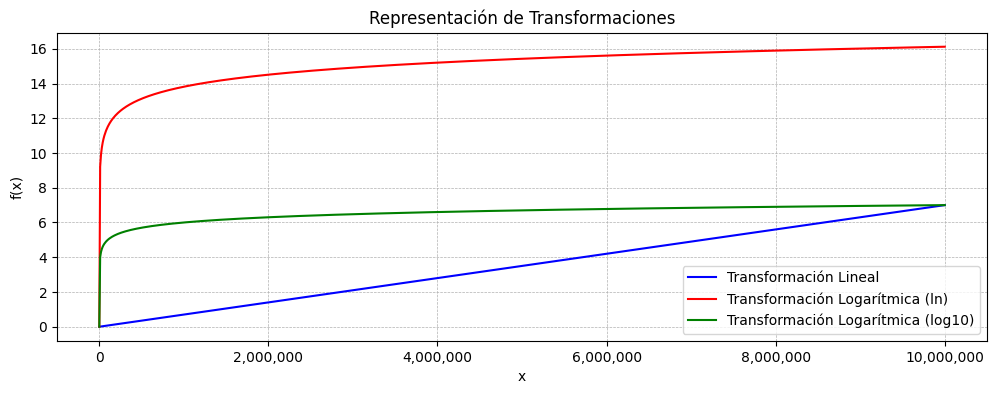

In [4]:
# Función para formatear ejes sin notación exponencial
# Si premerimos la escala logarítmica quitamos esto
def format_axes(ax):
     ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
     ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

def format_axes_2(ax):
     ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

x = np.linspace(1, 10**alpha, 1000)  # Evitamos 0 para el logaritmo

# Creamos una sola figura con todas las funciones
plt.figure(figsize=(12, 4))
plt.plot(x, g1_lin(x), label='Transformación Lineal', color='blue')
plt.plot(x, g1_log(x), label='Transformación Logarítmica (ln)', color='red')
plt.plot(x, g1_log10(x), label='Transformación Logarítmica (log10)', color='green')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Representación de Transformaciones')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)
format_axes(plt.gca())
plt.show()

La intuición se mantiene mejor con el logaritmo en base 10 que en el logaritmo natural, pero en el fondo da igual porque $$log(x) = log(10) \times log_{10}(x)$$

La diferencia fundamental está en que la transformación lineal mantiene una pendiente constante y que la logarítmica es _casi plana_ para valores altos y empieza a ser _significativa_ para valores pequeños.

### Paso 2

Ahora transformamos linealmente el intervalo $[0,\alpha]$ (o $[0,\alpha \times ln(10)]$ si hemos usado el logaritmo natural) en [0,1] dividiendo por el valor correspondiente. También podíamos llevar ambas magnitudes a intervalos de otra magnitud (luego vemos un experimento), pero al final lo que hacemos es transformar un segmento en otro con una transformación lineal.

In [5]:
# Transformación lineal
def g2_lin(x):
  # aux = alpha / (10**alpha -1)
  return g1_lin(x) / alpha

# Transformación logarítmica (logarito neperiano)
def g2_log(x):
  return g1_log(x) / np.log(10**alpha)

# Transformación logarítmica en base 10
def g2_log10(x):
  return g1_log10(x) / alpha

Vemos la gráfica

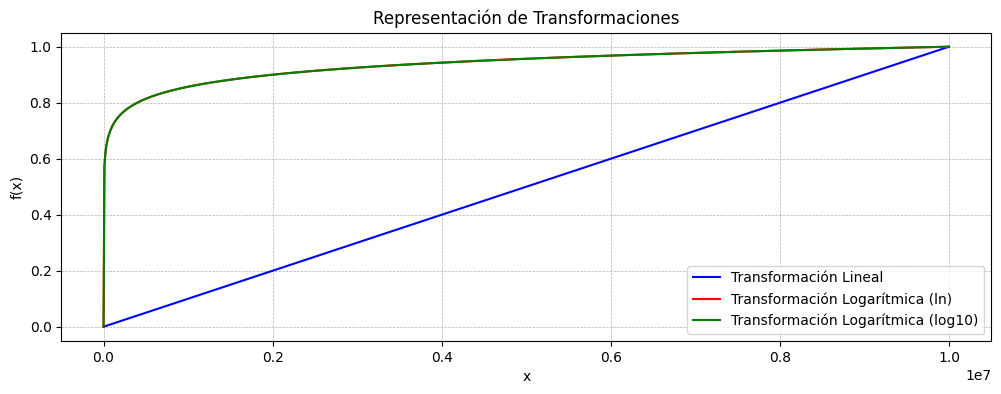

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(x, g2_lin(x), label='Transformación Lineal', color='blue')
plt.plot(x, g2_log(x), label='Transformación Logarítmica (ln)', color='red')
plt.plot(x, g2_log10(x), label='Transformación Logarítmica (log10)', color='green')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Representación de Transformaciones')
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)
plt.show()

Obviamente, al escalar a $[0,1]$ da igual la base del logaritmo.

Ya tenemos dos formas de escalar los valores de $NP$ al intervalo $[0,1]$ (ya veremos cuál da mejores resultados). Una vez que ambas magnitudes _accuracy_ y _NP_ están acotadas al intervalo $[0,1]$ podemos compararlas. Vamos a ver cómo construimos la función fitness.

## Propuesta 1: Basada en diferencias

El punto de partida es la función $$ f(x,y) = ac - NPt $$
donde _ac_ representa el _accuracy_ y _NPt_ el número de parámetros una vez reescalado

In [7]:
def f_1(ac,NPt):
  return ac - NPt

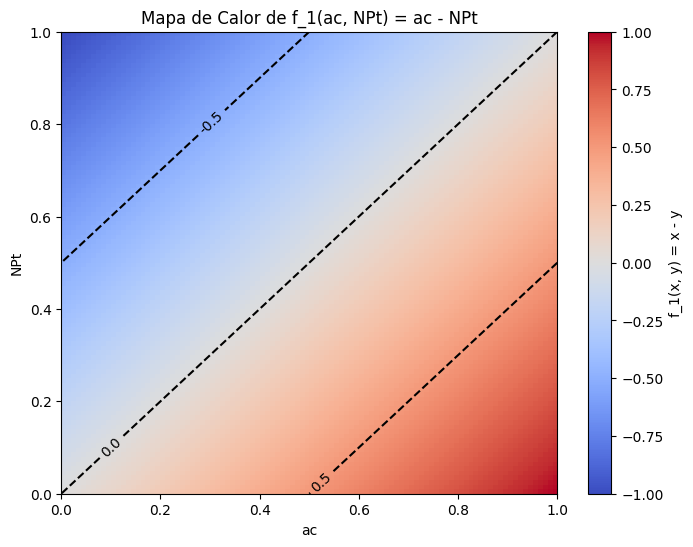

In [8]:
# Definimos el rango de valores de x e y
gridsize = 100
x = np.linspace(0, 1, gridsize)
y = np.linspace(0, 1, gridsize)
X, Y = np.meshgrid(x, y)
Z = f_1(X, Y)

# Graficamos el mapa de calor
plt.figure(figsize=(8, 6))
plt.imshow(Z, extent=[0,1,0,1], origin='lower', cmap='coolwarm', aspect='auto')
plt.colorbar(label='f_1(x, y) = x - y')

# Encontramos y marcamos los puntos donde la función toma el valor 0.5
contour = plt.contour(X, Y, Z, levels=[-0.5,0.0,0.5], colors='black', linestyles='dashed')
plt.clabel(contour, fmt="%.1f", colors='black')

plt.xlabel('ac')
plt.ylabel('NPt')
plt.title('Mapa de Calor de f_1(ac, NPt) = ac - NPt')
plt.show()


Esa función es _simétrica_ respecto a la recta que une el (0,1) con el (1,0), esto es, bajar 0.1 en $NPt$ es equivalente a subir 0.1 en _ac_.

Podemos cambiar esta relación usando un parámetro $\beta$

$$ f(x,y) = ac - (\beta * NPt)$$

In [9]:
beta = 0.5

def f_2(ac,NPt):
  return ac - (beta * NPt)

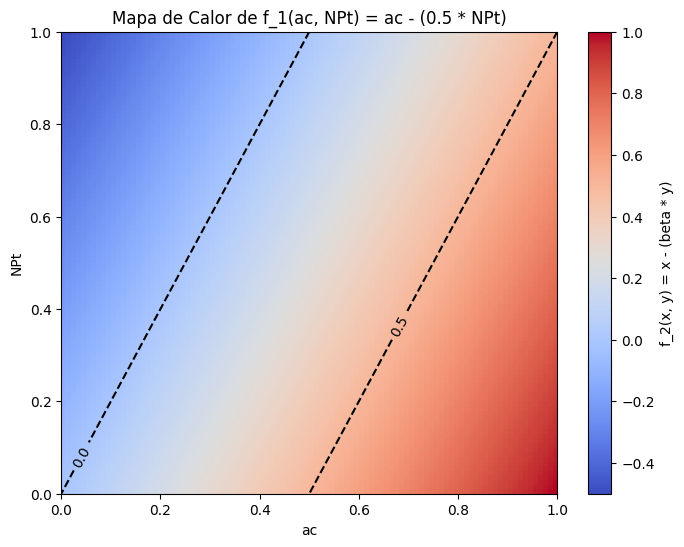

In [10]:
# Definimos el rango de valores de x e y
gridsize = 100
x = np.linspace(0, 1, gridsize)
y = np.linspace(0, 1, gridsize)
X, Y = np.meshgrid(x, y)
Z = f_2(X, Y)

# Graficamos el mapa de calor
plt.figure(figsize=(8, 6))
plt.imshow(Z, extent=[0,1,0,1], origin='lower', cmap='coolwarm', aspect='auto')
plt.colorbar(label='f_2(x, y) = x - (beta * y)')

# Encontramos y marcamos los puntos donde la función toma el valor 0.5
contour = plt.contour(X, Y, Z, levels=[0.0,0.5], colors='black', linestyles='dashed')
plt.clabel(contour, fmt="%.1f", colors='black')

plt.xlabel('ac')
plt.ylabel('NPt')
plt.title('Mapa de Calor de f_1(ac, NPt) = ac - (0.5 * NPt)')
plt.show()

Si $\beta = 0.5$ la _importancia_ de $NPt$ en el _fitness_ se reduce a la mitad y una disminución de dos décimas en $NPt$ es equivalente al aumento de una décima en _ac_.

Vemos la influencia de $\beta$ tomando varios valores de $\beta$





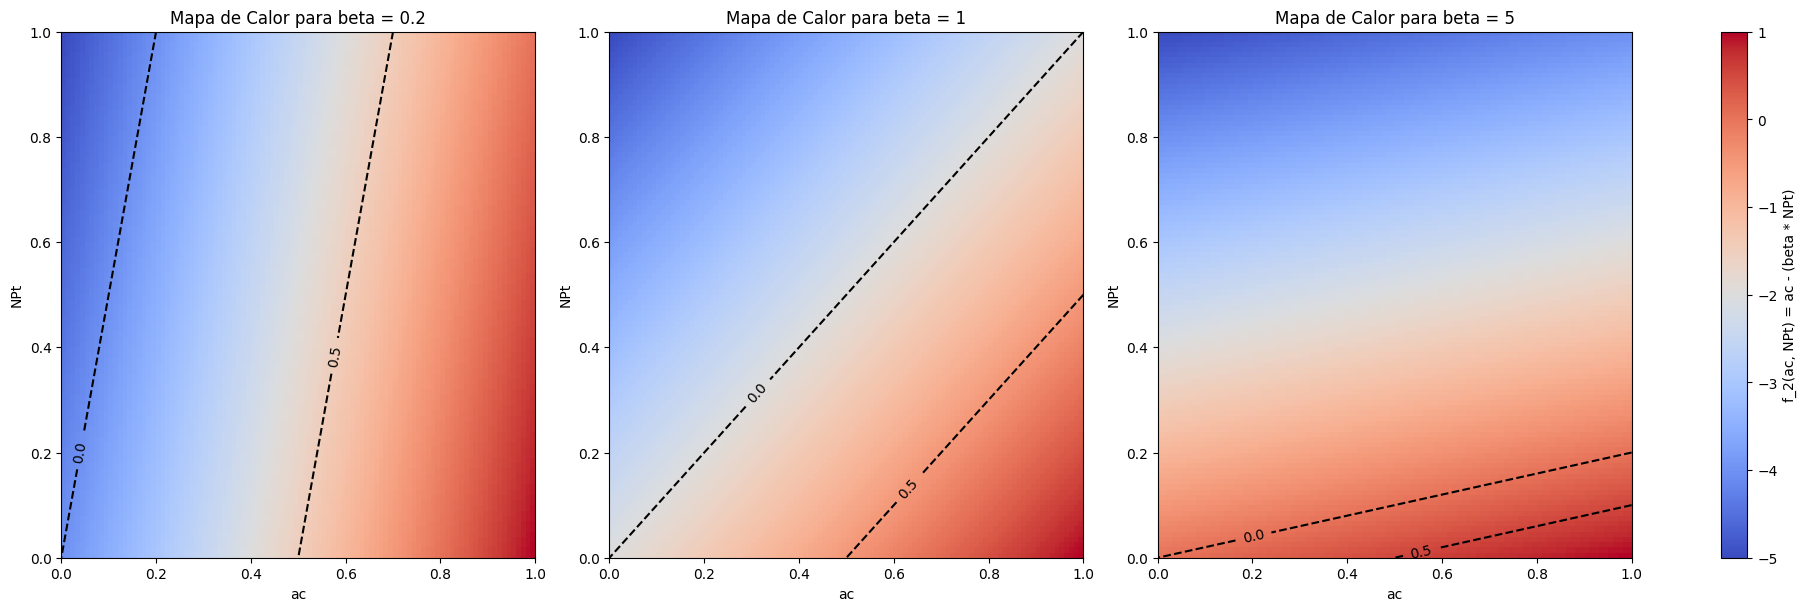

In [11]:
# Definimos la función
def f_2(ac, NPt, beta):
    return ac - (beta * NPt)

# Definimos el rango de valores de ac y NPt
gridsize = 100
x = np.linspace(0, 1, gridsize)
y = np.linspace(0, 1, gridsize)
X, Y = np.meshgrid(x, y)

# Valores de beta a evaluar
betas = [0.2, 1, 5]

# Crear figuras en una misma fila con layout corregido
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for ax, beta in zip(axes, betas):
    Z = f_2(X, Y, beta)
    im = ax.imshow(Z, extent=[0,1,0,1], origin='lower', cmap='coolwarm', aspect='auto')
    contour = ax.contour(X, Y, Z, levels=[0.0, 0.5], colors='black', linestyles='dashed')
    ax.clabel(contour, fmt="%.1f", colors='black')
    ax.set_xlabel('ac')
    ax.set_ylabel('NPt')
    ax.set_title(f'Mapa de Calor para beta = {beta}')

# Agregar colorbar
fig.colorbar(im, ax=axes.ravel().tolist(), label='f_2(ac, NPt) = ac - (beta * NPt)')

plt.show()


Para $\beta = 0.2$ el valor de $NPt$ es casi irrelevante, para $\beta = 1$ la importancia es la misma para _ac_ y $NPt$ y para $\beta = 5$ el valor de $NPt$ es mucho más importante que el valor de _ac_.

Pongamos ahora todo junto.

### 1.a Fitness basado en diferencia con transformación logarítmica

In [12]:
def f_diff_log(ac,NP,beta):
  NPt = g2_log(NP)
  return ac - (beta * NPt)

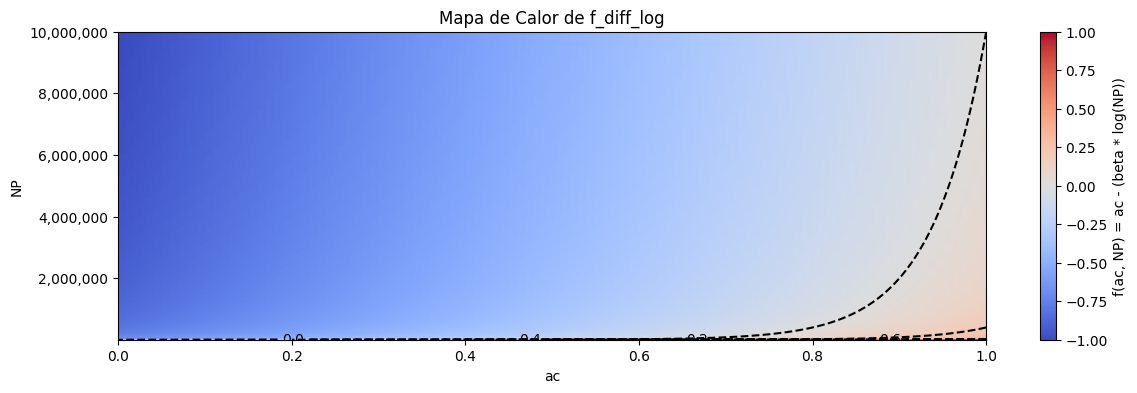

In [13]:
# Definimos beta
mi_beta = 1

# Definimos el rango de valores de x e y
gridsize_x = 100
gridsize_y = 500
x = np.linspace(0, 1, gridsize_x)
y = np.linspace(1, 10**alpha, gridsize_y)

X, Y = np.meshgrid(x, y)
Z = f_diff_log(X, Y,mi_beta)

# Graficamos el mapa de calor
plt.figure(figsize=(14, 4))
plt.imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', cmap='coolwarm', aspect='auto')
plt.colorbar(label='f(ac, NP) = ac - (beta * log(NP))')

# Encontramos y marcamos los puntos donde la función toma el valor 0.5
contour = plt.contour(X, Y, Z, levels=[0.0, 0.2, 0.4, 0.6], colors='black', linestyles='dashed')
plt.clabel(contour, fmt="%.1f", colors='black')

plt.xlabel('ac')
plt.ylabel('NP')
plt.title('Mapa de Calor de f_diff_log')
format_axes_2(plt.gca())
plt.show()

Vemos un detalle del mismo gráfico anterior, pero para valores de $NP$ pequeños

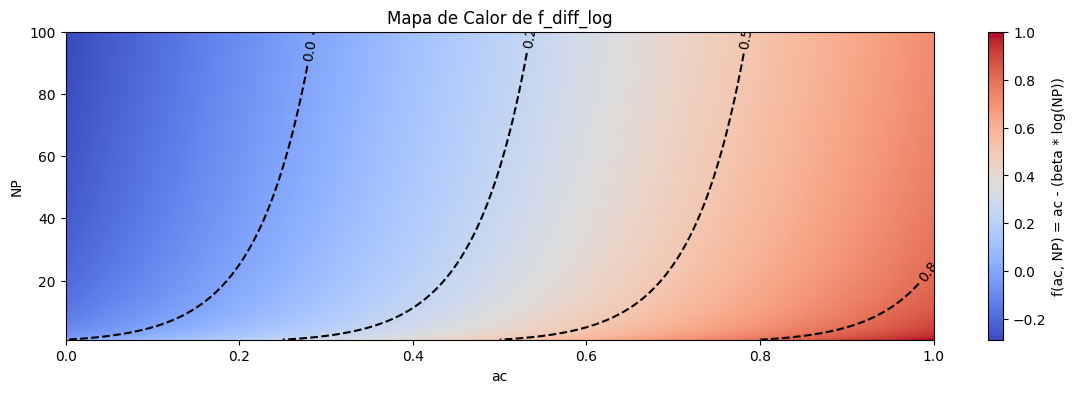

In [14]:
# Definimos el rango de valores de x e y
gridsize_x = 100
gridsize_y = 500
x = np.linspace(0, 1, gridsize_x)
y = np.linspace(1, 100, gridsize_y)

X, Y = np.meshgrid(x, y)
Z = f_diff_log(X, Y,mi_beta)

# Graficamos el mapa de calor
plt.figure(figsize=(14, 4))
plt.imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', cmap='coolwarm', aspect='auto')
plt.colorbar(label='f(ac, NP) = ac - (beta * log(NP))')

# Encontramos y marcamos los puntos donde la función toma el valor 0.5
contour = plt.contour(X, Y, Z, levels=[0.0, 0.25, 0.5, 0.8], colors='black', linestyles='dashed')
plt.clabel(contour, fmt="%.1f", colors='black')

plt.xlabel('ac')
plt.ylabel('NP')
plt.title('Mapa de Calor de f_diff_log')
format_axes_2(plt.gca())
plt.show()

El uso el logaritmo hace que sea muy difícil superar el valor de fitness de 0.8. Veamos qué ocurre con el escalado lineal.

### 1.b Fitness basado en diferencia con transformación lineal

In [15]:
def f_diff_lin(ac,NP,beta):
  NPt = g2_lin(NP)
  return ac - (beta * NPt)

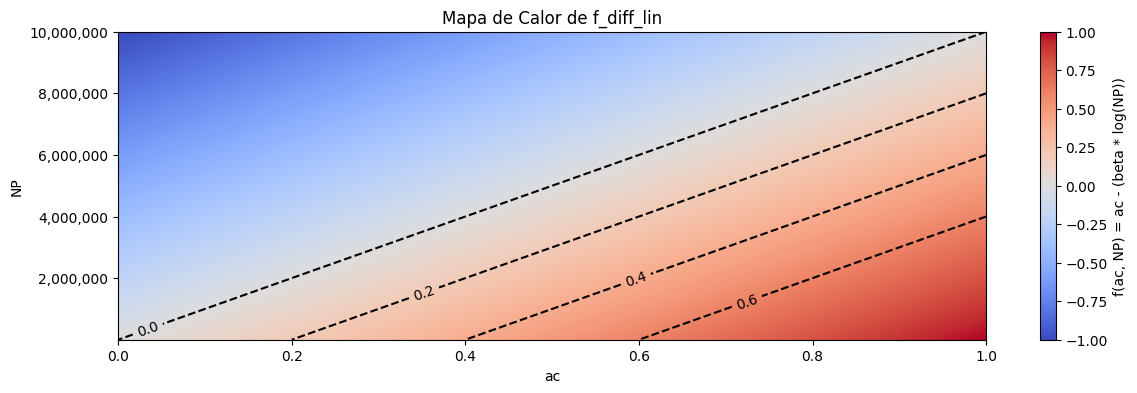

In [16]:
# Definimos beta
mi_beta = 1

# Definimos el rango de valores de x e y
gridsize_x = 100
gridsize_y = 500
x = np.linspace(0, 1, gridsize_x)
y = np.linspace(1, 10**alpha, gridsize_y)

X, Y = np.meshgrid(x, y)
Z = f_diff_lin(X, Y,mi_beta)

# Graficamos el mapa de calor
plt.figure(figsize=(14, 4))
plt.imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', cmap='coolwarm', aspect='auto')
plt.colorbar(label='f(ac, NP) = ac - (beta * log(NP))')

# Encontramos y marcamos los puntos donde la función toma el valor 0.5
contour = plt.contour(X, Y, Z, levels=[0.0, 0.2, 0.4, 0.6], colors='black', linestyles='dashed')
plt.clabel(contour, fmt="%.1f", colors='black')

plt.xlabel('ac')
plt.ylabel('NP')
plt.title('Mapa de Calor de f_diff_lin')
format_axes_2(plt.gca())
plt.show()

Tenemos que hablarlo, pero parece que la transformación lineal captura mejor el crecimiento de $NP$ en relación a _ac_. Además, podemos jugar con varios valores de $\beta$. Si $\beta$ sube, la influencia de $NP$ en el _fitness_ será mayor.

**Nota:** Puesto que hemos queremos que el _fitness_ sea cero si $NP > 10^\alpha$, cuando decidamos la función tenemos que sumarle un escalar para que el _fitness_obtenido por la fórmula sea siempre mayor o igual a cero.


## Propuesta 2: Basado en crecimiento hiperbólico
Ahora la función de partida es la combinación de dos funciones, ambas definidas en el intervalo $(0,1)$. La primera es $$f_1(ac) = \frac{1}{1-ac} -1 = \frac{ac}{1-ac}$$
La intuición de esta primera función es que los valores de la función crezcan muy rápidamente cuando _ac_ se acerque a 1. Tenemos que $f_1(0.9)=10$, $f_1(0.99)=100$, etc.

La segunda es
$$f_2(NPt) = \frac{1}{NPt}$$
que tiene el mismo ritmo de crecimiento, pero cuando $NPt$ se acerca a 0. De este modo $f_2(0.1)=10$, $f_2(0.01)=100$, etc.

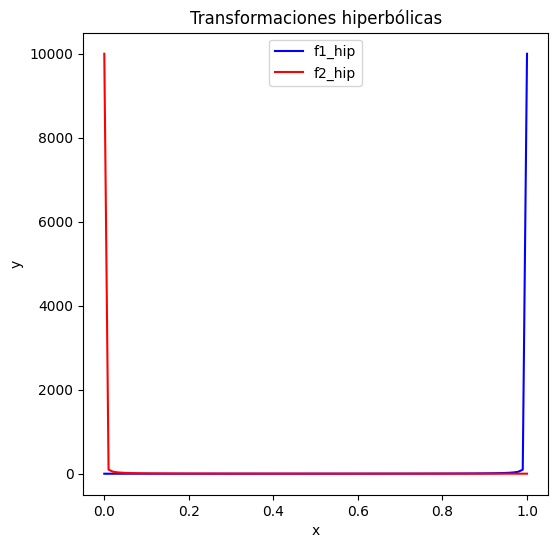

In [17]:
def f1_hip(x):
  return x / (1-x)

def f2_hip(x):
  return 1 / x

x = np.linspace(0.0001, 0.9999, 100)

# Crear una sola figura con todas las funciones
plt.figure(figsize=(6, 6))
plt.plot(x, f1_hip(x), label='f1_hip', color='blue')
plt.plot(x, f2_hip(x), label='f2_hip', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Transformaciones hiperbólicas')
plt.legend()
plt.show()

Vemos ahora una combinación de ambas funciones para tener una función bidimensional.

In [18]:
def f_hip(ac,NPt):
  return f1_hip(ac) * f2_hip(NPt)

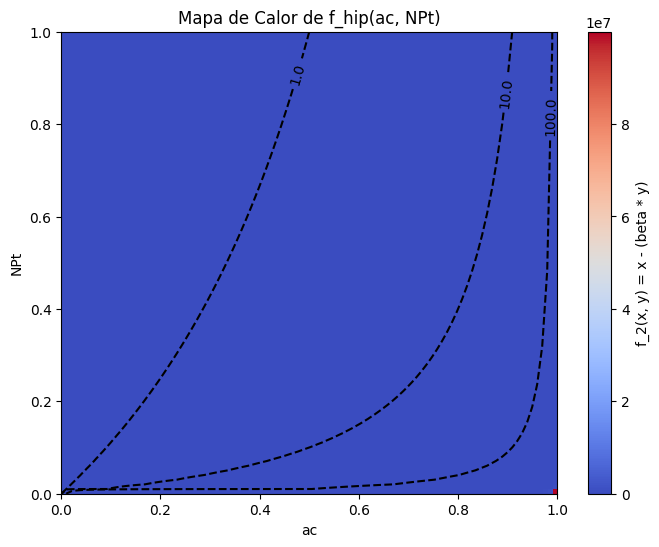

In [19]:
# Definimos el rango de valores de x e y
gridsize = 100
x = np.linspace(0, 0.9999, gridsize)
y = np.linspace(0.0001, 1, gridsize)
X, Y = np.meshgrid(x, y)
Z = f_hip(X, Y)

# Graficamos el mapa de calor
plt.figure(figsize=(8, 6))
plt.imshow(Z, extent=[0,1,0,1], origin='lower', cmap='coolwarm', aspect='auto')
plt.colorbar(label='f_2(x, y) = x - (beta * y)')

# Encontramos y marcamos los puntos donde la función toma el valor 0.5
contour = plt.contour(X, Y, Z, levels=[1,10,100], colors='black', linestyles='dashed')
plt.clabel(contour, fmt="%.1f", colors='black')

plt.xlabel('ac')
plt.ylabel('NPt')
plt.title('Mapa de Calor de f_hip(ac, NPt)')
plt.show()

Vemos que la función toma valores cercanos a cero en casi todo el cuadrado y sólo toma valores significativos si _ac_ se acerca a 1 y _NPt_ se acerca a 0. Podemos considerar cambiar la escala y en lugar de proyectar _ac_ y _NPt_ en intervalos de longitud 1, proyectarla en intervalos de longitud más pequeña.

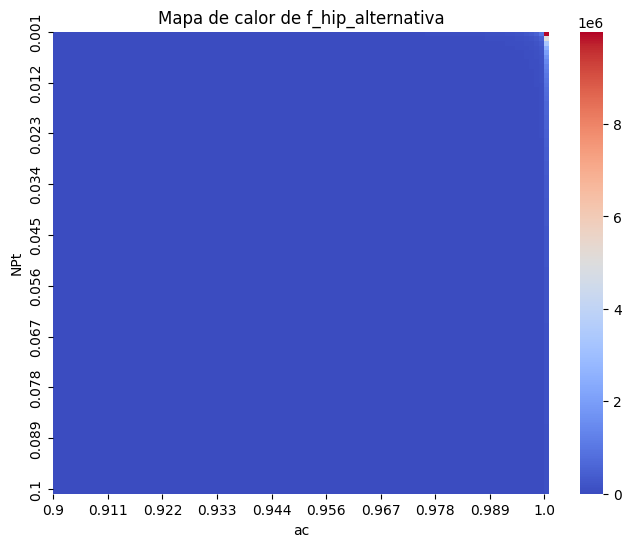

In [20]:
# Definir la función
def f_hip_alternativa(ac, NPt):
    return (ac / ((1-ac) * NPt)) - 1000

# Definir los rangos de valores (evitando 0 para prevenir división por cero)
x_values = np.linspace(0.9, 0.9999, 100)
y_values = np.linspace(0.001, 0.1, 100)

# Crear una malla de valores
X, Y = np.meshgrid(x_values, y_values)

# Evaluar la función en la malla
Z = f_hip_alternativa(X, Y)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Z, xticklabels=10, yticklabels=10, cmap="coolwarm", cbar=True)

# Ajustar los valores reales en los ejes
ax.set_xticks(np.linspace(0, len(x_values)-1, 10))
ax.set_xticklabels(np.round(np.linspace(x_values.min(), x_values.max(), 10), 3))
ax.set_yticks(np.linspace(0, len(y_values)-1, 10))
ax.set_yticklabels(np.round(np.linspace(y_values.min(), y_values.max(), 10), 3))

# Etiquetas
plt.xlabel("ac")
plt.ylabel("NPt")
plt.title("Mapa de calor de f_hip_alternativa")

# Mostrar el gráfico
plt.show()

Lo vemos en 3D

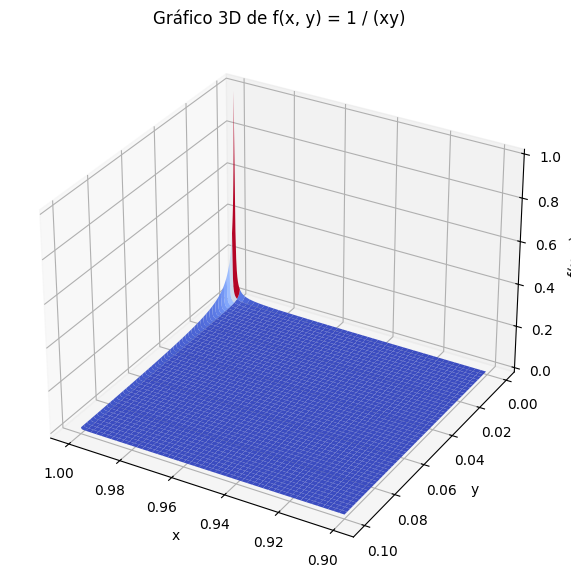

In [21]:
x_values = np.linspace(0.9, 0.9999, 500)
y_values = np.linspace(0.001, 0.1, 500)

# Crear una malla de valores
X, Y = np.meshgrid(x_values, y_values)

# Evaluar la función en la malla
Z = f_hip_alternativa(X, Y)

# Crear la figura y el eje 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Graficar la superficie con degradado y sin malla
ax.plot_surface(X, Y, Z, cmap='coolwarm', alpha=1, shade=True)

# Rotar la vista para poner (0,0) al fondo
ax.view_init(elev=30, azim=120)  # Ajusta la elevación y el ángulo

# Etiquetas
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.set_title("Gráfico 3D de f(x, y) = 1 / (xy)")

# Mostrar la gráfica
plt.show()


Podemos intentar evitar la zona extrema para tener un crecimiento controlado. Vemos el crecimiento si $ac \in [0,1-k]$ y $NPt \in [k,1]$

__Repasar:__ No entiendo que la gráfica no sea simétrica

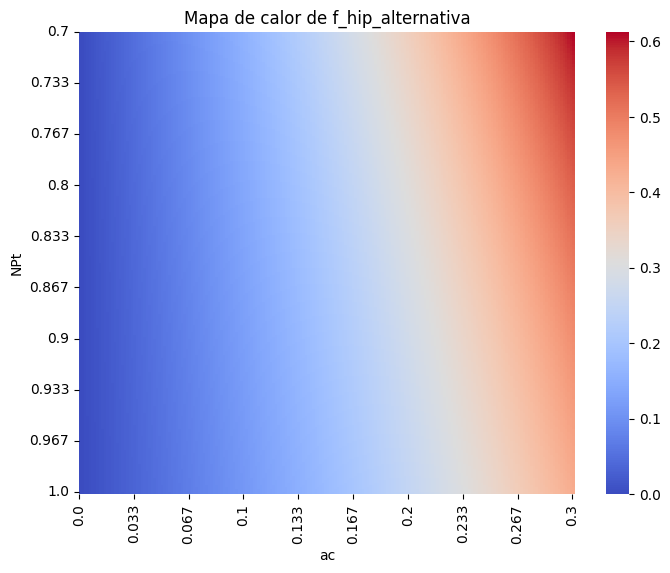

In [36]:
# Definir la función
# def f_hip_alternativa_2(ac, NPt):
#    return ac / ((1-ac) * NPt)

def f_hip_alternativa_2(ac, NPt):
    return f1_hip(ac) * f2_hip(NPt)

# Definir los rangos de valores (evitando 0 para prevenir división por cero)


k = 0.7
x_values = np.linspace(0, 1-k, 200)
y_values = np.linspace(k, 1, 200)

# Crear una malla de valores
X, Y = np.meshgrid(x_values, y_values)

# Evaluar la función en la malla
Z = f_hip_alternativa_2(X, Y)

plt.figure(figsize=(8, 6))
ax = sns.heatmap(Z, xticklabels=10, yticklabels=10, cmap="coolwarm", cbar=True)

# Ajustar los valores reales en los ejes
ax.set_xticks(np.linspace(0, len(x_values)-1, 10))
ax.set_xticklabels(np.round(np.linspace(x_values.min(), x_values.max(), 10), 3))
ax.set_yticks(np.linspace(0, len(y_values)-1, 10))
ax.set_yticklabels(np.round(np.linspace(y_values.min(), y_values.max(), 10), 3))

# Etiquetas
plt.xlabel("ac")
plt.ylabel("NPt")
plt.title("Mapa de calor de f_hip_alternativa")

# Mostrar el gráfico
plt.show()

Por completitud del estudio, podemos ver qué ocurre cuando ponemos juntos los procesos de escalado con esta función hiperbólica, pero está claro que con el crecimiento hiperbólico la pendiente es excesivamente plana antes del extremo.

### 2.a Fitness hiperbólico con transformación logarítmica


In [23]:
def f_hip_log(ac,NP):
  NPt = g2_log(NP)
  return f_hip(ac,NPt)

Valores de Z: 0.0 1611728965.2159111


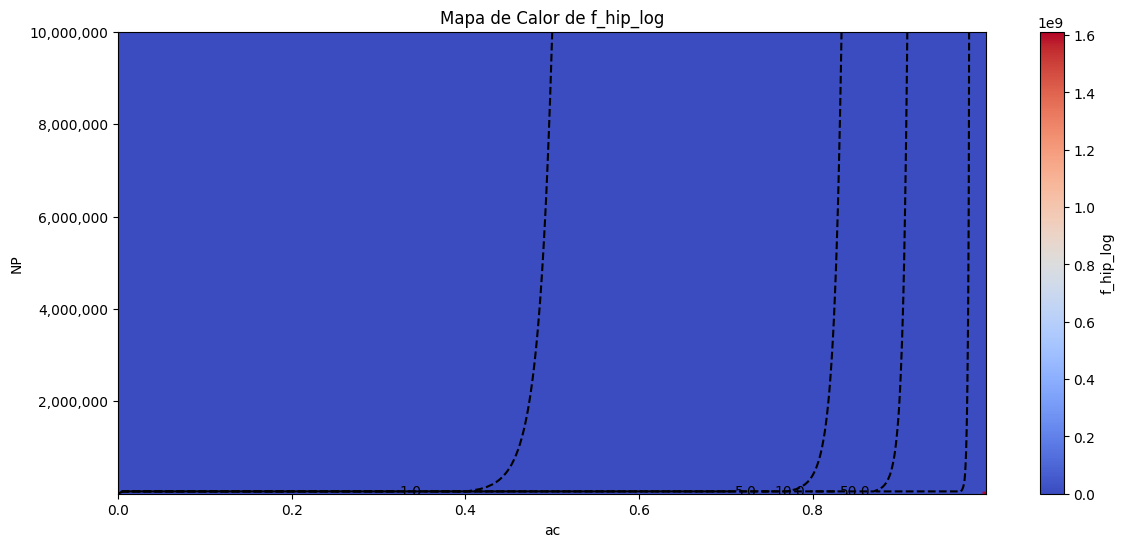

In [24]:
# Definimos el rango de valores de x e y
gridsize = 200
x = np.linspace(0, 0.9999, gridsize)
y = np.linspace(1.0001, 10**alpha, gridsize)
X, Y = np.meshgrid(x, y)
Z = f_hip_log(X, Y)

# Verificamos los valores de Z
print("Valores de Z:", np.min(Z), np.max(Z))

# Graficamos el mapa de calor con el rango correcto
plt.figure(figsize=(14, 6))
plt.imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', cmap='coolwarm', aspect='auto')
plt.colorbar(label='f_hip_log')

# Contornos visibles
contour = plt.contour(X, Y, Z, levels=[1, 5, 10, 50], colors='black', linestyles='dashed', linewidths=1.5)
plt.clabel(contour, fmt="%.1f", colors='black', fontsize=10)

# Etiquetas y formato
plt.xlabel('ac')
plt.ylabel('NP')
plt.title('Mapa de Calor de f_hip_log')
format_axes_2(plt.gca())
plt.show()

Por las curvas de nivel vemos que con esta representación, $NP$ es casi irrelevante.


### 2.a Fitness hiperbólico con transformación lineal


In [25]:
def f_hip_lin(ac,NP):
  NPt = g2_lin(NP)
  return f_hip(ac,NPt)

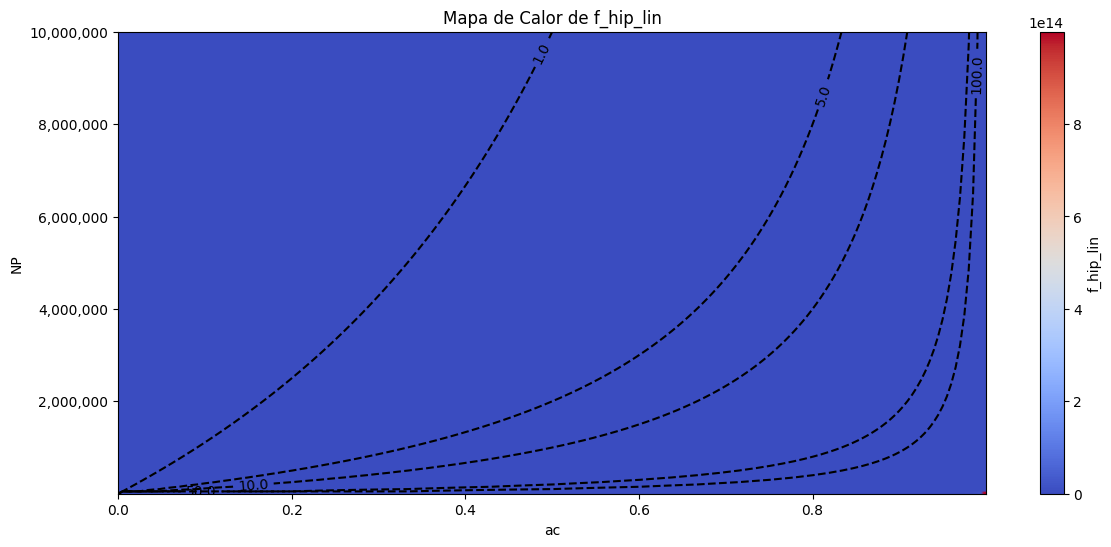

In [26]:
# Definimos el rango de valores de x e y
gridsize = 200
x = np.linspace(0, 0.9999, gridsize)
y = np.linspace(1.0001, 10**alpha, gridsize)
X, Y = np.meshgrid(x, y)
Z = f_hip_lin(X, Y)

# Graficamos el mapa de calor con el rango correcto
plt.figure(figsize=(14, 6))
plt.imshow(Z, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', cmap='coolwarm', aspect='auto')
plt.colorbar(label='f_hip_lin')

# Contornos visibles con valores adecuados
contour = plt.contour(X, Y, Z, levels=[1, 5, 10, 50,100], colors='black', linestyles='dashed', linewidths=1.5)
plt.clabel(contour, fmt="%.1f", colors='black', fontsize=10)

# Etiquetas y formato
plt.xlabel('ac')
plt.ylabel('NP')
plt.title('Mapa de Calor de f_hip_lin')
format_axes_2(plt.gca())
plt.show()

# Conclusiones
* El principal problema es el rango en el que se mueve el _accuracy_ y el número de parámetros _NP_.
* La transformación logarítmica para valores muy altos distorsiona mucho el sentido de _crecimiento_. Por ejemplo, una variación de 0.1 en el exponente 7 (en base 10) produce una diferencia de aproximadamente dos millones de parámetros

In [ ]:
round(10**7 - 10**6.9,1)

2056717.7

* El escalado lineal mantiene el crecimiento constante. Tenemos que debatir si queremos que esto ocurra así,
* Respecto a las funciones de _fitness_ podemos seguir explorando más funciones, pero hay dos aspectos clave: (1) ¿Queremos crecimiento constante o queremos que la _fitness_ se dispare en determinados casos (con la contrapartida de crecimiento casi plano otras veces?; (2) ¿Le damos la misma importancia a la mejora en _accuracy_ y en _NP_?

En fin, tenemos mucho que debatir...

## Propuesta 3: Crecimiento parabólico

El crecimiento hiperbólico es casi plano fuera del extremo. Vamos a ver el crecimiento parabólico.


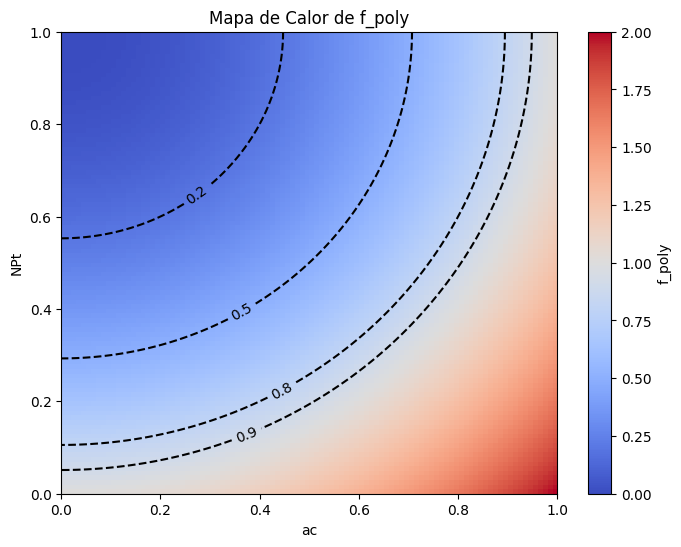

In [49]:
def f_poly(ac,NPt):
  return ac**2 + (NPt - 1)**2

# Definimos el rango de valores de x e y
gridsize = 100
x = np.linspace(0, 1, gridsize)
y = np.linspace(0, 1, gridsize)
X, Y = np.meshgrid(x, y)
Z = f_poly(X, Y)

# Graficamos el mapa de calor
plt.figure(figsize=(8, 6))
plt.imshow(Z, extent=[0,1,0,1], origin='lower', cmap='coolwarm', aspect='auto')
plt.colorbar(label='f_poly')

# Encontramos y marcamos los puntos donde la función toma el valor 0.5
contour = plt.contour(X, Y, Z, levels=[0.2,0.5,0.8,0.9], colors='black', linestyles='dashed')
plt.clabel(contour, fmt="%.1f", colors='black')

plt.xlabel('ac')
plt.ylabel('NPt')
plt.title('Mapa de Calor de f_poly')
plt.show()

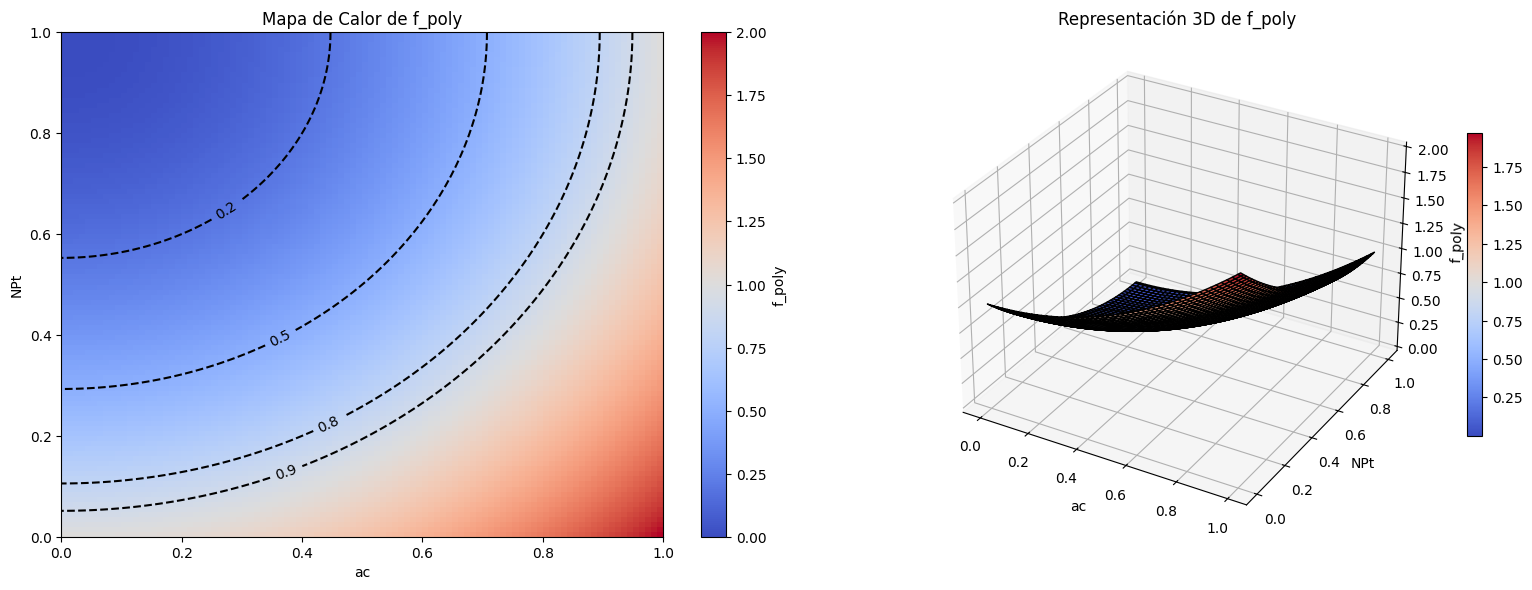

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Import necesario para gráficos 3D

# Definimos la función
def f_poly(ac, NPt):
    return ac**2 + (NPt - 1)**2

# Definimos el rango de valores de x e y
gridsize = 100
x = np.linspace(0, 1, gridsize)
y = np.linspace(0, 1, gridsize)
X, Y = np.meshgrid(x, y)
Z = f_poly(X, Y)

# Creamos una figura con dos subplots
fig = plt.figure(figsize=(16, 6))

# Mapa de calor
ax1 = fig.add_subplot(1, 2, 1)
heatmap = ax1.imshow(Z, extent=[0, 1, 0, 1], origin='lower', cmap='coolwarm', aspect='auto')
ax1.set_title('Mapa de Calor de f_poly')
ax1.set_xlabel('ac')
ax1.set_ylabel('NPt')

# Contornos
contour = ax1.contour(X, Y, Z, levels=[0.2, 0.5, 0.8, 0.9], colors='black', linestyles='dashed')
ax1.clabel(contour, fmt="%.1f", colors='black')

# Barra de color
cbar = fig.colorbar(heatmap, ax=ax1)
cbar.set_label('f_poly')

# Gráfico 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surface = ax2.plot_surface(X, Y, Z, cmap='coolwarm', edgecolor='k')
ax2.set_title('Representación 3D de f_poly')
ax2.set_xlabel('ac')
ax2.set_ylabel('NPt')
ax2.set_zlabel('f_poly')

# Barra de color para la gráfica 3D
fig.colorbar(surface, ax=ax2, shrink=0.6)

# Ajustar el diseño
plt.tight_layout()
plt.show()


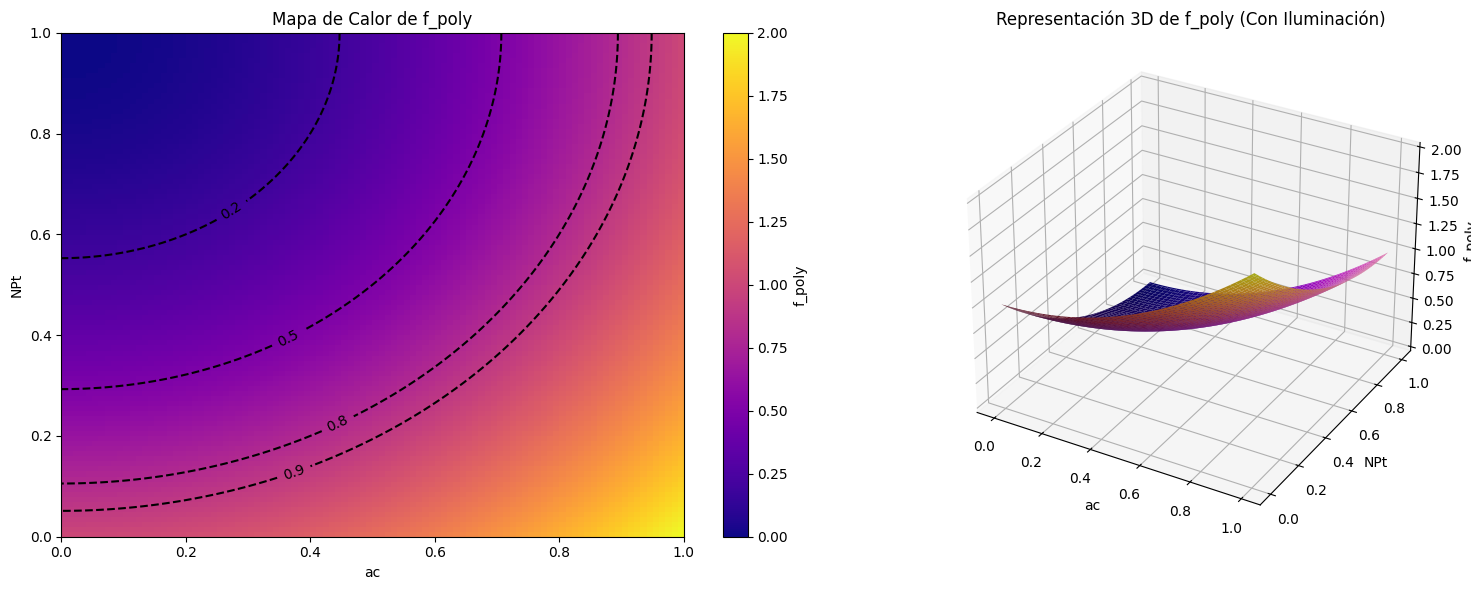

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LightSource  # Para mejorar la iluminación

# Definimos la función
def f_poly(ac, NPt):
    return ac**2 + (NPt - 1)**2

# Definimos el rango de valores de x e y
gridsize = 100
x = np.linspace(0, 1, gridsize)
y = np.linspace(0, 1, gridsize)
X, Y = np.meshgrid(x, y)
Z = f_poly(X, Y)

# Creamos una figura con dos subplots
fig = plt.figure(figsize=(16, 6))

# Mapa de calor
ax1 = fig.add_subplot(1, 2, 1)
heatmap = ax1.imshow(Z, extent=[0, 1, 0, 1], origin='lower', cmap='plasma', aspect='auto')
ax1.set_title('Mapa de Calor de f_poly')
ax1.set_xlabel('ac')
ax1.set_ylabel('NPt')

# Contornos
contour = ax1.contour(X, Y, Z, levels=[0.2, 0.5, 0.8, 0.9], colors='black', linestyles='dashed')
ax1.clabel(contour, fmt="%.1f", colors='black')

# Barra de color
cbar = fig.colorbar(heatmap, ax=ax1)
cbar.set_label('f_poly')

# Gráfico 3D con mejor iluminación
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ls = LightSource(azdeg=315, altdeg=45)  # Dirección de la fuente de luz
rgb = ls.shade(Z, cmap=plt.cm.plasma, vert_exag=0.1, blend_mode='soft')

# Superficie con mejor iluminación y sin bordes negros
surface = ax2.plot_surface(X, Y, Z, facecolors=rgb, edgecolor='none')
ax2.set_title('Representación 3D de f_poly (Con Iluminación)')
ax2.set_xlabel('ac')
ax2.set_ylabel('NPt')
ax2.set_zlabel('f_poly')

# Ajustar el diseño
plt.tight_layout()
plt.show()
